### Checking this notebook is running in Pyhon environment with ArcGIS Pro license

In [10]:
# arcpy only works when ArcGIS is installed to the local computer
# must use the ArcGIS Pro Python environment.
# ArcGIS active license is required to run arcpy
import sys
print(sys.executable)

c:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\python.exe


In [11]:
import sys
print(sys.version)

3.13.7 | packaged by Anaconda, Inc. | (main, Sep 11 2025, 16:13:29) [MSC v.1938 64 bit (AMD64)]


In [12]:
import site
print(site.getsitepackages())

['c:\\Program Files\\ArcGIS\\Pro\\bin\\Python\\envs\\arcgispro-py3', 'c:\\Program Files\\ArcGIS\\Pro\\bin\\Python\\envs\\arcgispro-py3\\Lib\\site-packages']


In [13]:
import arcpy

### Testing the defined functions - CSV Conversion

In [14]:
print(os.getcwd())

y:\aa_GSS_Student_Engagement_Training\Sho\GeoDBToText


In [35]:
# Imports
import arcpy
import os
import csv


# Input parameters
GeoDB = arcpy.GetParameterAsText(0) # The input geodatabase (Workspace)
DatasetTitle = arcpy.GetParameterAsText(1) # The output geodatabase
Attribution = arcpy.GetParameterAsText(2) # Attribution (citation) for the dataset
Abstract = arcpy.GetParameterAsText(3) # Abstract
TermsOfUse = arcpy.GetParameterAsText(4) # Terms of use. Non-sensitive government data is public domain
DatasetContact = arcpy.GetParameterAsText(5) # Contact for the dataset
Delimiter = arcpy.GetParameterAsText(6) # Fields delimiter. A pipe was chosen to avoid ambiguity with the commas in the WKT geometry data. You can change it back to a comma or whatever you want here.

# set the workspace
arcpy.env.workspace = GeoDB

In [36]:
def ExportCSV(FeatureClass, output_path):
    try:
        CSVFilePath = os.path.join(output_path, FeatureClass + ".csv")

        # delete file if exists
        if os.path.exists(CSVFilePath):
            arcpy.AddMessage("File exists: " + CSVFilePath + ". Deleted")
            os.remove(CSVFilePath)

        # open file ONCE
        with open(CSVFilePath, "w", newline="", encoding="utf-8") as CSVFile:

            fields = arcpy.ListFields(FeatureClass)
            field_names = [f.name for f in fields]
            field_names.insert(0, "Shape@WKT")

            # metadata
            CSVFile.write(DatasetTitle + "\n")
            CSVFile.write(Abstract + "\n")
            CSVFile.write(Attribution + "\n")
            CSVFile.write("Spatial reference: " +
                          arcpy.Describe(FeatureClass).spatialReference.exportToString() + "\n")
            CSVFile.write(TermsOfUse + "\n")

            CSVFile.write("\n")

            # header
            CSVFile.write(Delimiter.join(field_names) + "\n")

            # data
            with arcpy.da.SearchCursor(FeatureClass, field_names) as cursor:
                for row in cursor:
                    CSVFile.write(Delimiter.join([str(v) for v in row]) + "\n")

    except Exception as e:
        arcpy.AddMessage("Export failed for FeatureClass: " +
                          FeatureClass + " " + str(e))

In [16]:
ExportCSV("Y:/aa_GSS_Student_Engagement_Training/Sho/GeoDBToText/data/winona_lake.shp", "./data/winona_lake.csv")

In [17]:
# Checking if SHP file gets converted
ExportCSV("Y:/aa_GSS_Student_Engagement_Training/Sho/GeoDBToText/data/Peatland_Watershed_Protection_Areas_(WPAs)/Peatland_Watershed_Protection_Areas_(WPAs).shp", "./data/peatland_SHP.csv")

### Checking which file contains metadata

In [18]:
with open("Y:/aa_GSS_Student_Engagement_Training/Sho/GeoDBToText/data/Peatland_Watershed_Protection_Areas_(WPAs)/Peatland_Watershed_Protection_Areas_(WPAs).cpg") as f:
    print(f.read())

UTF-8


In [19]:
with open("Y:/aa_GSS_Student_Engagement_Training/Sho/GeoDBToText/data/Peatland_Watershed_Protection_Areas_(WPAs)/Peatland_Watershed_Protection_Areas_(WPAs).prj") as f:
    print(f.read())

PROJCS["NAD_1983_UTM_Zone_15N",GEOGCS["GCS_North_American_1983",DATUM["D_North_American_1983",SPHEROID["GRS_1980",6378137.0,298.257222101]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["False_Easting",500000.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",-93.0],PARAMETER["Scale_Factor",0.9996],PARAMETER["Latitude_Of_Origin",0.0],UNIT["Meter",1.0]]


In [20]:
%pip install dbfread
%pip install polars

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [21]:
from dbfread import DBF
import polars as pl

table = DBF("Y:/aa_GSS_Student_Engagement_Training/Sho/GeoDBToText/data/Peatland_Watershed_Protection_Areas_(WPAs)/Peatland_Watershed_Protection_Areas_(WPAs).dbf")
df = pl.DataFrame(list(table))
print(df)

shape: (21, 7)
┌──────────┬───────────┬───────────────────┬──────────────────┬────────┬──────────────┬────────────┐
│ objectid ┆ acres     ┆ sna_name          ┆ type             ┆ abbrev ┆ shape_Leng   ┆ shape_Area │
│ ---      ┆ ---       ┆ ---               ┆ ---              ┆ ---    ┆ ---          ┆ ---        │
│ i64      ┆ f64       ┆ str               ┆ str              ┆ str    ┆ f64          ┆ f64        │
╞══════════╪═══════════╪═══════════════════╪══════════════════╪════════╪══════════════╪════════════╡
│ 1        ┆ 7932.878  ┆ East Rat Root     ┆ Peatland         ┆ WPA    ┆ 31677.656883 ┆ 3.2103e7   │
│          ┆           ┆ River Peatland S… ┆ Watershed        ┆        ┆              ┆            │
│          ┆           ┆                   ┆ Protection …     ┆        ┆              ┆            │
│ 2        ┆ 3810.022  ┆ Hole-in-the-Bog   ┆ Peatland         ┆ WPA    ┆ 24084.44922  ┆ 1.5419e7   │
│          ┆           ┆ Peatland SNA      ┆ Watershed        ┆        ┆    

In [22]:
with open("Y:/aa_GSS_Student_Engagement_Training/Sho/GeoDBToText/data/Peatland_Watershed_Protection_Areas_(WPAs)/Peatland_Watershed_Protection_Areas_(WPAs).xml", "r", encoding="utf-8") as f:
    print(f.read()[:10000])

<?xml version="1.0" encoding="UTF-8"?><metadata>
    <idinfo>
        <citation>
            <citeinfo>
                <origin/>
                <pubdate>20260304</pubdate>
                <title>Peatland Watershed Protection Areas (WPAs)</title>
                <pubinfo>
                    <publish>Minnesota Department of Natural Resources (DNR)</publish>
                </pubinfo>
                <onlink>http://gisdata.mn.gov/dataset/bdry-watershed-protection-areas</onlink>
                <onlink>https://operations.gis.data.mn.gov/api/publicdownload/download/657/bdry_watershed_protection_areas.gpkg</onlink>
            </citeinfo>
        </citation>
        <descript>
            <abstract>This dataset represents the Peatland Watershed Protection Areas (WPAs) associated with Minnesota's 18 Peatland Scientific and Natural Areas (SNAs). WPAs were delineated in the early-mid 1980s as part of the Protection of Ecologically Significant Peatlands in Minnesota project and are referenced

In [23]:
with open("Y:/aa_GSS_Student_Engagement_Training/Sho/GeoDBToText/data/Peatland_Watershed_Protection_Areas_(WPAs)/Peatland_Watershed_Protection_Areas_(WPAs).shp.xml", "r", encoding="utf-8") as f:
    print(f.read()[:10000])

<?xml version="1.0"?>
<metadata xml:lang="en">
	<Esri>
		<CreaDate>20260624</CreaDate>
		<CreaTime>13294700</CreaTime>
		<ArcGISFormat>1.0</ArcGISFormat>
		<SyncOnce>FALSE</SyncOnce>
		<DataProperties><itemProps><itemName Sync="TRUE">Peatland_Watershed_Protection_Areas_(WPAs)</itemName><imsContentType Sync="TRUE">002</imsContentType><nativeExtBox><westBL Sync="TRUE">286611.134700</westBL><eastBL Sync="TRUE">601031.400500</eastBL><southBL Sync="TRUE">5204520.843000</southBL><northBL Sync="TRUE">5431524.711800</northBL><exTypeCode Sync="TRUE">1</exTypeCode></nativeExtBox><itemSize Sync="TRUE">0.036</itemSize><itemLocation><linkage Sync="TRUE">file://\\gssfilesrv1\GSS\aa_GSS_Student_Engagement_Training\Sho\Sample_Data\Peatland_Watershed_Protection_Areas_(WPAs)\Peatland_Watershed_Protection_Areas_(WPAs).shp</linkage><protocol Sync="TRUE">Local Area Network</protocol></itemLocation></itemProps><coordRef><type Sync="TRUE">Projected</type><geogcsn Sync="TRUE">GCS_North_American_1983</geogcsn>

In [24]:
# Checking if a file with metadata gets converted
ExportCSV("Y:/aa_GSS_Student_Engagement_Training/Sho/GeoDBToText/data/Peatland_Watershed_Protection_Areas_(WPAs)/Peatland_Watershed_Protection_Areas_(WPAs).xml", "./data/peatland_xml.csv")

### GeoPandas for quick data inspection

#### Instaling GeoPandas

In [25]:
import sys
print(sys.executable)

c:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\python.exe


In [26]:
!pip show geopandas

Name: geopandas
Version: 1.1.3
Summary: Geographic pandas extensions
Home-page: 
Author: 
Author-email: Kelsey Jordahl <kjordahl@alum.mit.edu>
License-Expression: BSD-3-Clause
Location: C:\Users\gsssmu\AppData\Roaming\Python\Python313\site-packages
Requires: numpy, packaging, pandas, pyogrio, pyproj, shapely
Required-by: 


In [27]:
%pip install geopandas
%pip install contextily

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached click-8.4.2-py3-none-any.whl (119 kB)
Note: you may need to restart the kernel to use updated packages.


In [28]:
import geopandas

import contextily
import matplotlib.pyplot as plt

#### Visual inspection of data with GeoPandas

In [29]:
w_lake = geopandas.read_file("./data/winona_lake.shp")
w_lake

"./data/Peatland_Watershed_Protection_Areas_(WPAs)/Peatland_Watershed_Protection_Areas_(WPAs).shp"

'./data/Peatland_Watershed_Protection_Areas_(WPAs)/Peatland_Watershed_Protection_Areas_(WPAs).shp'

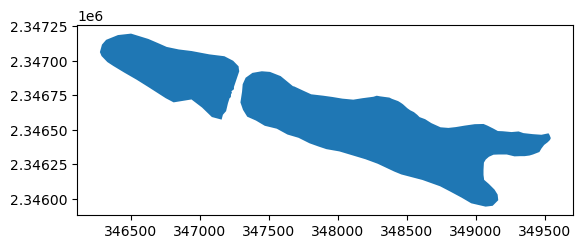

In [30]:
w_lake.plot()
plt.show()

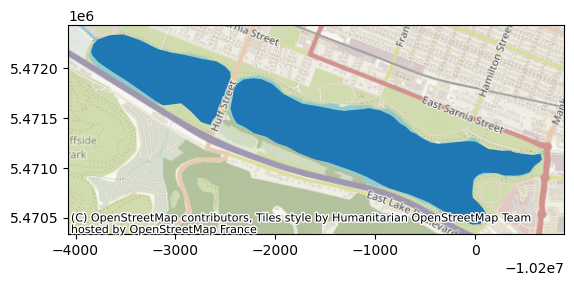

In [31]:
#contextily requires Web Mercator (EPSG:3857)
w_lake = w_lake.to_crs(epsg=3857)

fig, ax = plt.subplots()
w_lake.geometry.plot(ax=ax, markersize=1)
contextily.add_basemap(ax)
plt.show()

In [32]:
peatland = geopandas.read_file("./data/Peatland_Watershed_Protection_Areas_(WPAs)/Peatland_Watershed_Protection_Areas_(WPAs).shp")
peatland.head()


,objectid,acres,sna_name,type,abbrev,shape_Leng,shape_Area,geometry
0,1,7932.878,East Rat Root River Peatland SNA,Peatland Watershed Protection Area,WPA,31677.656883,3.210335e+07,"POLYGON ((484047.555 5373856.794, 484458.814 5..."
1,2,3810.022,Hole-in-the-Bog Peatland SNA,Peatland Watershed Protection Area,WPA,24084.449220,1.541867e+07,"POLYGON ((407983.41 5240437.696, 408187.032 52..."
2,3,7080.662,Lost Lake Peatland SNA,Peatland Watershed Protection Area,WPA,46080.130615,2.865454e+07,"POLYGON ((539636.613 5295223.467, 539234.857 5..."
3,4,1173.050,Lost River Peatland SNA,Peatland Watershed Protection Area,WPA,8832.509196,4.747183e+06,"POLYGON ((398182.929 5319881.853, 398595.703 5..."
4,5,1914.450,Lost River Peatland SNA,Peatland Watershed Protection Area,WPA,10647.450222,7.747533e+06,"POLYGON ((417140.133 5332815.316, 417542.526 5..."


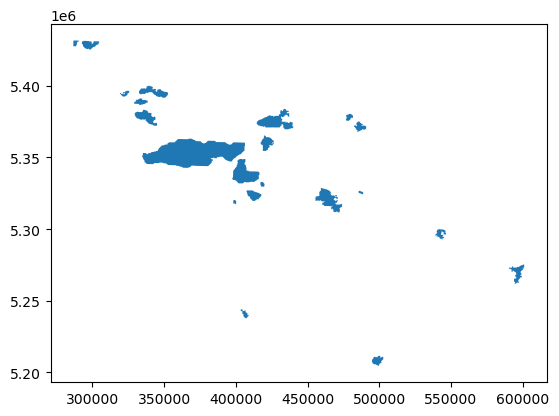

In [33]:
peatland.plot()
plt.show()

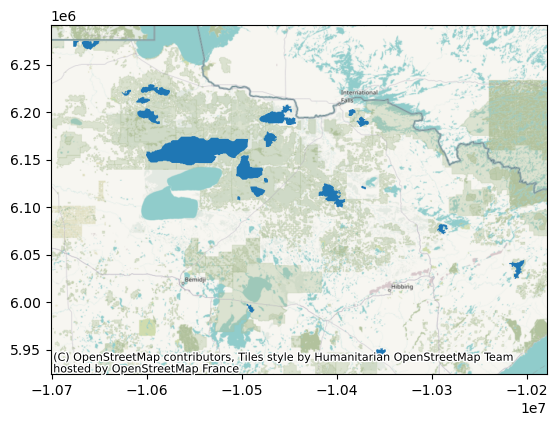

In [34]:
#contextily requires Web Mercator (EPSG:3857)
peatland = peatland.to_crs(epsg=3857)

fig, ax = plt.subplots()
peatland.geometry.plot(ax=ax, markersize=1)
contextily.add_basemap(ax)
plt.show()